# Predicción de precio de diamantes mediante Redes Neuronales

En este proyecto se construye y entrena una red neuronal para un problema de regresión, con el objetivo de predecir el precio de un diamante a partir de sus características. Se realiza un preprocesamiento de los datos, incluyendo su división en conjuntos de entrenamiento, validación y prueba. Posteriormente, el modelo se entrena utilizando técnicas de regularización y callbacks, como Early Stopping y el ajuste dinámico del learning rate. Finalmente, se evalúa el rendimiento mediante métricas de error y el análisis de predicciones frente a valores reales.

**Objetivo:** construir un modelo capaz de predecir el precio de un diamante en función de sus características.

**Tecnología utilizada:**
- Python
- NumPy, Pandas
- TensorFlow / Keras
- Scikit-learn
- Matplotlib

**Resultados:**
- MAE ≈ 330 $
- R² = 0.98 (alta capacidad explicativa del modelo)
- Buen ajuste general, sin evidencias claras de sobreajuste.

Importación de librerias necesarias

In [ ]:
import tensorflow as tf

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

También vamos a utilizar algunas herramientas de la librería Sklearn (https://scikit-learn.org/stable/)

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score

Vamos a trabajar con el dataset **Diamods**, un conocido dataset sacado del libro ***ggplot2: Elegant Graphics for Data Analysis*** de Hadley Wickham. El dataset contiene cerca de 54.000 diamantes con diferentes características, entre ellas su precio.

**Carga y mezcla del dataset:** Se cargan los datos en la variable dataset y a continuación, se reordenan aleatoriamente las observaciones, fijando una semilla, con la instrucción `.sample(frac = 1,random_state = 42)`.

Este paso es importante para:
- **Evitar sesgos por orden**: Los datos originales pueden estar ordenados de alguna forma (por fecha de registro, por precio, etc.), lo que podría introducir sesgos en la partición train/validation/test.
- **Reproducibilidad**: El parámetro `random_state=42` garantiza que la mezcla sea siempre la misma, permitiendo reproducir los experimentos.
- **Distribución uniforme**: Asegura que los conjuntos de entrenamiento, validación y prueba tengan una distribución similar de las características.

In [ ]:
dataset = pd.read_csv('/content/diamonds.csv')
dataset = dataset.sample(frac=1, random_state=42)
print(dataset.head(5))
print(dataset.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
       Unnamed: 0  carat        cut color clarity  depth  table  price     x  \
1388         1389   0.24      Ideal     G    VVS1   62.1   56.0    559  3.97   
50052       50053   0.58  Very Good     F    VVS2   60.0   57.0   2201  5.44   
41645       41646   0.40      Ideal     E    VVS2   62.1   55.0   1238  4.76   
42377       42378   0.43    Premium     E    VVS2   60.8   57.0   1304  4.92   
17244       17245   1.55      Ideal     E     SI2   62.3   55.0   6901  7.44   

          y     z  
1388   4.00  2.47  
50052  5.42  3.26  
41645  4.74  2.95  
42377  4.89  2.98  
17244  7.37  4.61  
(53940, 11)


Se realiza una exploración inicial del dataset para analizar las variables disponibles, como el color, la claridad, el precio y las dimensiones del diamante, así como los tipos de datos presentes.

In [ ]:
print(dataset.info())

<class 'pandas.core.frame.DataFrame'>
Index: 53940 entries, 1388 to 15795
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  object 
 3   color       53940 non-null  object 
 4   clarity     53940 non-null  object 
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.9+ MB
None


In [ ]:
print(dataset.describe())

         Unnamed: 0         carat         depth         table         price  \
count  53940.000000  53940.000000  53940.000000  53940.000000  53940.000000   
mean   26970.500000      0.797940     61.749405     57.457184   3932.799722   
std    15571.281097      0.474011      1.432621      2.234491   3989.439738   
min        1.000000      0.200000     43.000000     43.000000    326.000000   
25%    13485.750000      0.400000     61.000000     56.000000    950.000000   
50%    26970.500000      0.700000     61.800000     57.000000   2401.000000   
75%    40455.250000      1.040000     62.500000     59.000000   5324.250000   
max    53940.000000      5.010000     79.000000     95.000000  18823.000000   

                  x             y             z  
count  53940.000000  53940.000000  53940.000000  
mean       5.731157      5.734526      3.538734  
std        1.121761      1.142135      0.705699  
min        0.000000      0.000000      0.000000  
25%        4.710000      4.720000     

**Descripción de las características del dataset**

El dataset **Diamonds** es un conjunto de datos clásico introducido por Hadley Wickham en su libro "ggplot2: Elegant Graphics for Data Analysis". Contiene información de aproximadamente 54,000 diamantes con las siguientes características:

### Variables del Dataset

| Variable | Tipo | Descripción |
|----------|------|-------------|
| **price** | int | Precio del diamante en dólares estadounidenses ($326 - $18,823). Es nuestra **variable objetivo** (y). |
| **carat** | float | Peso del diamante en quilates (0.2 - 5.01). 1 quilate = 0.2 gramos. Es el factor más importante que influye en el precio. |
| **cut** | categórica | Calidad del corte del diamante. Valores ordenados de peor a mejor: Fair, Good, Very Good, Premium, Ideal. El corte afecta cómo el diamante refleja la luz. |
| **color** | categórica | Color del diamante, de D (incoloro, mejor) a J (ligeramente amarillo, peor). Los diamantes más valiosos son los más incoloros. |
| **clarity** | categórica | Claridad o pureza del diamante, indica la cantidad de inclusiones (imperfecciones internas). De peor a mejor: I1, SI2, SI1, VS2, VS1, VVS2, VVS1, IF. |
| **depth** | float | Porcentaje de profundidad total = z / mean(x, y) * 100. Indica las proporciones del diamante. |
| **table** | float | Ancho de la faceta superior (mesa) como porcentaje del diámetro más ancho. Afecta el brillo. |
| **x** | float | Longitud del diamante en milímetros. |
| **y** | float | Anchura del diamante en milímetros. |
| **z** | float | Profundidad del diamante en milímetros. |
| **vol** | float | Volumen calculado = x * y * z (característica derivada creada en el preprocesamiento). |

**Filtrado de registros inconsistentes:** Se eliminan del dataset aquellos registros en los que alguna de las dimensiones `x`, `y` o `z` toma el valor 0, ya que estas variables representan el tamaño físico del diamante y dichos valores corresponden a errores en los datos. Mantener estos registros introduciría ruido en el modelo.

Importancia del filtrado:
- **Integridad física**: Un diamante real no puede tener dimensión cero en ningún eje. Estos valores son claramente errores de medición o registro.
- **Calidad del modelo**: Los datos erróneos introducen ruido y pueden confundir al modelo durante el entrenamiento.
- **Cálculo del volumen**: Posteriormente se calcula el volumen como `x * y * z`, y cualquier cero produciría un volumen de 0, lo cual es físicamente imposible.

**Creación de una nueva característica:** en lugar de utilizar directamente las dimensiones `x`, `y` y `z`, se define una nueva variable más representativa: **el volumen del diamante** `vol`, calculado a como el producto de estas tres dimensiones. Esta transformación permite combinar la información de las tres medidas en una única característica que resume mejor el tamaño real del diamante.

Este paso resulta útil porque:
- **Síntesis de información**: El volumen proporciona una medida más intuitiva y compacta del tamaño del diamante que las tres dimensiones por separado.
- **Reducción de dimensionalidad**: se reemplazan tres variables (x, y, z), por una sola (vol) que captura la esencia del tamaño.
- **Relación con el precio**: el tamaño del diamante está estrechamente relacionado con su peso (carat) y, por tanto, con el precio del diamante.
- **Mejor generalización**: una característica derivada relevante facilita la detección de patrones y mejora la generalización.

In [ ]:
dataset = dataset.loc[(dataset[['x','y','z']]!= 0).all(axis=1)]
dataset['vol'] = dataset['x']*dataset['y']*dataset['z']

Se examina la distribución de la variable cut para conocer la composición del dataset.

In [ ]:
print(dataset.cut.value_counts())

cut
Ideal        21548
Premium      13780
Very Good    12081
Good          4902
Fair          1609
Name: count, dtype: int64


**Codificación numérica de las variables categóricas:** Las columnas `cut`, `color` y `clarity` contienen valores categóricos en formato texto. Para poder utilizarlas en la red neuronal, se transforman a valores numéricos mediante LabelEncoder de scikit-learn. Este paso es necesario porque los modelos de aprendizaje automático solo pueden trabajar con datos numéricos.

Importancia de la codificación:
- **Requisito del modelo:** las redes neuronales trabajan exclusivamente con datos numéricos.
- **Preservación de categorías:** cada valor categórico se representa con un número distinto, manteniendo la distinción entre categorías.
- **Eficiencia computacional:** las operaciones numéricas son más eficientes que el procesamiento de texto.

Se utiliza LabelEncoder en lugar de One-Hot Encoding para evitar un aumento excesivo de la dimensionalidad del dataset. Aunque estas variables no tienen un orden intrínseco natural, el modelo puede aprender relaciones no lineales entre las categorías codificadas y el precio.

In [ ]:
label = LabelEncoder()
dataset['cut'] = label.fit_transform(dataset[['cut']])
dataset['color'] = label.fit_transform(dataset[['color']])
dataset['clarity'] = label.fit_transform(dataset[['clarity']])
print(dataset.info())

<class 'pandas.core.frame.DataFrame'>
Index: 53920 entries, 1388 to 15795
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53920 non-null  int64  
 1   carat       53920 non-null  float64
 2   cut         53920 non-null  int64  
 3   color       53920 non-null  int64  
 4   clarity     53920 non-null  int64  
 5   depth       53920 non-null  float64
 6   table       53920 non-null  float64
 7   price       53920 non-null  int64  
 8   x           53920 non-null  float64
 9   y           53920 non-null  float64
 10  z           53920 non-null  float64
 11  vol         53920 non-null  float64
dtypes: float64(7), int64(5)
memory usage: 5.3 MB
None


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


**Definición de las entradas y salidas:**

- **Variable de entrada `X`:** se construye a partir de las características 'carat', 'cut', 'color', 'clarity' y 'vol'.

- **Variable objetivo `y`:** corresponde al precio de los diamantes.

Para mejorar la eficiencia computacional, los datos se convierten a matrices y vectores de **NumPy**, y posteriormente se aplica **MinMaxScaler** de *scikit-learn* para normalizar las variables antes de entrenar el modelo.

Importancia de este paso:
- **Selección de variables:** se utilizan características relevantes para la predicción del precio.
-  **Eficiencia computacional:** las operaciones matriciales con NumPy son más rápidas y adecuadas para el entrenamiento de modelos.
- **Compatibilidad:** librerías como TensorFlow/Keras trabajan de forma nativa con arrays de NumPy.

### Las 4C's de los Diamantes

El valor de un diamante se determina tradicionalmente por las **4C's** (en inglés):

1. **Carat (Quilate)**: El peso del diamante. A mayor quilataje, mayor precio (relación exponencial).
2. **Cut (Corte)**: La calidad del tallado. Un buen corte maximiza el brillo y el "fuego" del diamante.
3. **Color**: La ausencia de color. Los diamantes más valiosos son completamente incoloros.
4. **Clarity (Claridad)**: La ausencia de inclusiones y defectos. Menos imperfecciones = mayor valor.

### Variables Utilizadas vs. No Utilizadas

**Variables utilizadas para la predicción (X)**:
- `carat`: Factor principal de precio
- `cut`: Calidad del tallado (codificada numéricamente)
- `color`: Color del diamante (codificada numéricamente)
- `clarity`: Pureza del diamante (codificada numéricamente)
- `vol`: Volumen calculado (x*y*z)

**Variables NO utilizadas**:
- `depth`: Aunque indica proporciones, su información está parcialmente contenida en el volumen
- `table`: Similar al depth, menos relevante para el precio que las 4C's
- `x`, `y`, `z`: Se usan indirectamente a través del volumen calculado


**Normalización de las entradas `X`:** para mejorar la eficiencia computacional, los datos se convierten a matrices y vectores de **NumPy**, y se normalizan mediante MinMaxScaler de scikit-learn, escalando los valores al rango [0,1]. Este proceso evita que variables con escalas mayores dominen el aprendizaje y facilita la convergencia del descenso del gradiente.

Importancia de la normalización:
- **Convergencia del gradiente:** sin normalización, variables con rangos grandes (como carat o vol) pueden dominar el gradiente y dificultar el entrenamiento.
- **Escala común:** todas las características quedan en el mismo rango, permitiendo que el modelo las trate de forma equilibrada.
- **Optimización más estable:** el descenso del gradiente converge más rápido y de forma más estable con datos normalizados.
- **Evitar saturación:** valores muy grandes pueden saturar las funciones de activación y reducir la capacidad de aprendizaje.

In [ ]:
X = dataset[['carat', 'cut', 'color', 'clarity', 'vol']].to_numpy()
y = dataset[['price']].to_numpy() # resulta evidente que el precio es nuestra etiqueta

bn = MinMaxScaler()
X = bn.fit_transform(X)


**División de los datos:** el dataset se divide en tres subconjuntos:

*   **Entrenamiento - 70% (`X_train`):** se utiliza para ajustar los pesos del modelo y aprender los patrones presentes en los datos.
*   **Validación - 20% (`X_validation`):** se emplea durante el entrenamiento para monitorizar el rendimiento, ajustar hiperparámetros y detectar posibles problemas de sobreajuste.
*   **Prueba - 10% (`X_test`):** se reserva exclusivamente para la evaluación final del modelo con datos no vistos, proporcionando una estimación imparcial de su capacidad de generalización.

Las etiquetas correspondientes se separan de forma consistente para cada subconjunto.

Importancia de la división:
- Permite evaluar el modelo en datos independientes.
- Ayuda a detectar sobreajuste durante el entrenamiento.
- Proporciona una estimación realista del rendimiento del modelo en producción.


In [ ]:
num_total = X.shape[0] # con shape obtenemos el tamaño (el número de elementos)

Num_train = int(num_total * 0.7)
Num_validation = int(num_total * 0.2)
Num_test = int(num_total * 0.1)

X_train, X_validation, X_test = tf.split(X, num_or_size_splits=[Num_train,
                                                         Num_validation,
                                                         Num_test]
                                     )
y_train, y_validation, y_test = tf.split(y, num_or_size_splits=[Num_train,
                                                               Num_validation,
                                                               Num_test])

# Construcción del modelo

Se construye una red neuronal de regresión con capas densas y funciones de activación ReLU, utilizando técnicas de regularización y callbacks para mejorar la generalización.

# Modelo principal

Este modelo incorpora múltiples técnicas para mejorar el rendimiento:

**Arquitectura en embudo:** reduce progresivamente las neuronas (256 → 128 → 64 → 32 → 1)
   - Las primeras capas capturan patrones generales
   - Las capas posteriores refinan y combinan esos patrones
   - Reduce progresivamente la dimensionalidad hacia la salida

**Función de activación ReLU (Rectified Linear Unit):**
   - f(x) = max(0, x)
   - Computacionalmente eficiente
   - Evita el problema del gradiente desvaneciente
   - Permite aprender relaciones no lineales complejas
  
**Inicialización `he_normal`:**
   - Diseñada específicamente para activaciones ReLU
   - Mantiene la varianza de las activaciones estable

**Batchnormalization:** Normaliza las activaciones de la capa anterior
   - Estabiliza y acelera el entrenamiento
   - Permite LR más altos
   - Reduce la sensibilidad a la inicialización de pesos
   - Actúa como regularizador adicional

**Dropout (0.15-0.20):** durante el entrenamiento, desactiva aleatoriamente un porcentaje de las neuronas para prevenir el sobreajuste y mejorar la generalización.
   - Previene el sobreajuste
   - Mejora la capacidad de generalización
   - Valores moderados para no perder demasiada información



In [ ]:
# =============================================================================
# CONSTRUCCIÓN DEL MODELO DE RED NEURONAL
# =============================================================================

# Importamos las librerías necesarias de Keras/TensorFlow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

# Número de características de entrada
n_features = X_train.shape[1]
print(f"Número de características de entrada: {n_features}")

# =============================================================================
# MODELO PRINCIPAL: Arquitectura con técnicas avanzadas de regularización
# =============================================================================

modelo = Sequential([
    # Capa de entrada + Primera capa oculta - 256 neuronas
    Dense(256, activation='relu', input_shape=(n_features,),
          kernel_initializer='he_normal',  # Inicialización He para ReLU
          name='capa_entrada'),

    # BatchNormalization: Normaliza las activaciones de la capa anterior
    BatchNormalization(name='bn_1'),

    # Dropout: Durante el entrenamiento, desactiva aleatoriamente el 20% de las neuronas
    Dropout(0.2, name='dropout_1'),

    # Segunda capa oculta - 128 neuronas
    Dense(128, activation='relu', kernel_initializer='he_normal', name='capa_oculta_2'),
    BatchNormalization(name='bn_2'),
    Dropout(0.2, name='dropout_2'),

    # Tercera capa oculta - 64 neuronas
    Dense(64, activation='relu', kernel_initializer='he_normal', name='capa_oculta_3'),
    BatchNormalization(name='bn_3'),
    Dropout(0.15, name='dropout_3'),

    # Cuarta capa oculta - 32 neuronas
    Dense(32, activation='relu', kernel_initializer='he_normal', name='capa_oculta_4'),

    # Capa de salida - 1 neurona para regresión
    # Activación lineal (por defecto) porque predecimos un valor continuo (precio)
    Dense(1, name='capa_salida')
])

Número de características de entrada: 5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


El objetivo del ejercicio es predecir el precio de los diamantes, que es una variable continua. Por tanto, se trata de un problema de regresión supervisada, ya que el modelo aprende a partir de ejemplos etiquetados donde se conoce el valor del precio.

Este problema lo resolveremos mediante una red neuronal *feedforward*, un tipo de red en la que la información fluye en una única dirección, desde la capa de entrada hasta la capa de salida, sin ciclos ni retroalimentación interna. Este tipo de redes es adecuado en este caso ya que trabajamos con datos tabulares, donde cada muestra es independiente del resto y no existe dependencia temporal entre observaciones (descartando arquitecturas recurrentes).

La  red comienza con una capa de entrada Dense de 256 neuronas y una función de activación ReLu. Esta capa permite aprender relaciones no lineales entre las características del diamante y su precio. A continuación se añade una capa  BatchNormalization para normalizar las activaciones de la capa anterior y una capa Dropout con valor de 0.20, que se utiliza para reducir la dependencia de neuronas concretas controlando así el sobreajuste del modelo.

A continuación se añaden más capas ocultas con (con activación ReLU). Se usa una estructura de embudo (256 -> 128 -> 64 -> 32) para ir reduciendo progresivamente la representación y quedarnos con patrones más útiles para la predicción. Entre capas se vuelve a aplicar BatchNormalization y Dropout (0.20) para estabilizar el entrenamiento y mejorar la generalización del modelo.

Por ultimo, la red termina con una capa de salida con una única neurona con activación lineal, ya que al tratarse de un problema de regresión se deben predecir valores contínuos para el precio.

# Compilación del modelo

La compilación configura el proceso de aprendizaje: cómo se calcularán los errores y cómo se actualizarán los pesos de la red.

**Optimizador: Adam (Adaptive Moment Estimation)** combina las ventajas de:
- Momentum: acelera la convergencia en direcciones consistentes
- RMSprop: adapta el learning rate para cada parámetro

Configuración de Adam:
- Learning Rate inicial: 0.001
- Beta1: 0.9 (momento de primer orden)
- Beta2: 0.999 (momento de segundo orden)
- Epsilon: 1e-07 (estabilidad numérica)

**Función de pérdida: MSE (Mean Squared Error)**
- MSE = (1/n) * Σ(y_real - y_pred)²
- Penaliza errores grandes más que errores pequeños (ideal para regresión)
- Diferenciable en todos los puntos
- Estándar para problemas de regresión

**Métrica para monitorizar durante el entrenamiento: MAE (Mean Absolute Error)**
- Más interpretable que MSE (error promedio en unidades originales: dólares)
- Menos sensible a outliers que MSE

In [ ]:
# =============================================================================
# COMPILACIÓN DEL MODELO
# =============================================================================

learning_rate = 0.001  # Valor inicial del learning rate

optimizer = Adam(learning_rate=learning_rate)

# Compilamos el modelo
modelo.compile(
    optimizer=optimizer,
    loss='mse',       # Función de pérdida: Error Cuadrático Medio (MSE)
    metrics=['mae']   # Metrica para monitorizar durante el entrenamiento: MAE (Mean Absolute Error)
)

Al compilar el modelo utilizamos los siguientes parametros:

Se define el optimizador Adam con un *learning rate* inicial de 0.001, ya que permite ajustar los pesos de forma eficiente y realizar actualizaciones más pequeñas y estables durante el entrenamiento.

Como función de pérdida se utiliza el error cuadratico medio (MSE), que es la función estándar en problemas de regresión. Esta función penaliza más los errores grandes, lo que resulta adecuado cuando se trabaja con precios, ya que errores elevados deben tener un mayor impacto en el aprendizaje del modelo.

Por último, como métrica de evaluación, elegimos el error medio absoluto (MAE), ya que es fácil de interpretar y se expresa en las mismas unidades que la variable objetivo, en este caso el precio de los diamantes.

# Entrenamiento del modelo

El entrenamiento es el proceso donde el modelo aprende los patrones de los datos. Utilizaremos callbacks para optimizar automáticamente el proceso de entrenamiento.

Definimos los callbacks (funciones que se ejecutan durante el entrenamiento)

1. **EarlyStopping:** Detiene el entrenamiento si no hay mejora. Esto previene el sobreajuste y ahorra tiempo de cómputo

2. **ReduceLROnPlateau:** Reduce el learning rate cuando el modelo se estanca. Permite un entrenamiento más fino cuando el modelo deja de mejorar

Definimos los hiperparámetros de entrenamiento
- `epochs`: Número máximo de épocas (EarlyStopping puede detenerlo antes)
- `batch_size`: Tamaño del lote (número de muestras por actualización de pesos)

In [ ]:
# =============================================================================
# ENTRENAMIENTO DEL MODELO CON CALLBACKS AVANZADOS
# =============================================================================

# EarlyStopping: Mecanismo de control del entrenamiento para evitar sobreajuste
early_stopping = EarlyStopping(
    monitor='val_loss',             # Se observa la pérdida en el conjunto de validación
    patience=15,                    # Número de épocas sin mejora antes de la detención del entrenamiento
    restore_best_weights=True,       # Restaura los pesos del mejor modelo (mejor punto de validación)
    verbose=1,                      # Muestra mensajes cuando se activa
    min_delta=0.0001                # Mejora mínima para considerarse significativa
)

# ReduceLROnPlateau: Reduce el learning rate para un entrenamiento más fino
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',             # Monitorea la pérdida en validación
    factor=0.5,                     # Reduce el LR a la mitad
    patience=8,                     # Épocas sin mejora antes de reducir LR
    min_lr=1e-6,                    # Learning rate mínimo
    verbose=1                       # Muestra mensajes cuando se reduce el LR
)

# Definimos los hiperparámetros de entrenamiento
epochs = 200        # Número máximo de épocas (EarlyStopping puede detenerlo antes)
batch_size = 64     # Tamaño del lote (número de muestras por actualización de pesos)


# Entrenamos el modelo
h_train = modelo.fit(
    X_train, y_train,                                 # Datos y etiquetas de entrenamiento
    validation_data=(X_validation, y_validation),     # Datos de validación
    epochs=epochs,                                    # Número máximo de épocas
    batch_size=32,                                    # Tamaño del lote
    callbacks=[early_stopping, reduce_lr],            # Callbacks para aplicar EarlyStopping y ReduceLR
    verbose = 1                                       # Muestra el progreso del entrenamiento
)



Epoch 1/200
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - loss: 24141062.0000 - mae: 3356.7515 - val_loss: 954025.6875 - val_mae: 619.6767 - learning_rate: 0.0010
Epoch 2/200
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 2053923.8750 - mae: 942.9064 - val_loss: 736706.8125 - val_mae: 558.0922 - learning_rate: 0.0010
Epoch 3/200
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 1685834.7500 - mae: 859.2905 - val_loss: 654685.0000 - val_mae: 497.6305 - learning_rate: 0.0010
Epoch 4/200
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 1474499.5000 - mae: 805.5350 - val_loss: 590943.2500 - val_mae: 453.7280 - learning_rate: 0.0010
Epoch 5/200
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 1442938.2500 - mae: 808.4506 - val_loss: 641638.1875 - val_mae: 510.6804 - learning_rate: 0.0010
Epoch 6/200
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1296889.3750 - mae: 770.0308 - val_loss: 535381.3125 - val_mae: 423.1924 - learning_rate: 0.0010
Epoch 7/200
1180/1180 ━━━━━━━━━━━━━━━

Antes de entrenar el modelo se define el EarlyStopping, un mecanismo de control del entrenamiento que ayuda a evitar el sobreajuste. Este método supervisa la pérdida del conjunto de validación y detiene el entrenamiento cuando dicha pérdida deja de mejorar durante una cantidad determinada de épocas. Además se recuperan automáticamente los mejores pesos obtenidos en validación, mejorando así la capacidad de generalización del modelo.

El modelo se entrena utilizando el conjunto de entrenamiento y se valida con el conjunto de  validación durante 200 épocas, con un tamaño de lote de 32. El uso del callback de EarlyStopping permite que el entrenamiento se detenga antes si el modelo deja de mejorar, evitando así entrenamientos innecesarios y reduciendo el riesgo de sobreajuste.

# Visualización de resultados del entrenamiento


RESULTADOS DEL ENTRENAMIENTO

Épocas entrenadas: 86
Mejor pérdida en validación: 343913.38
Mejor MAE en validación: 322.19


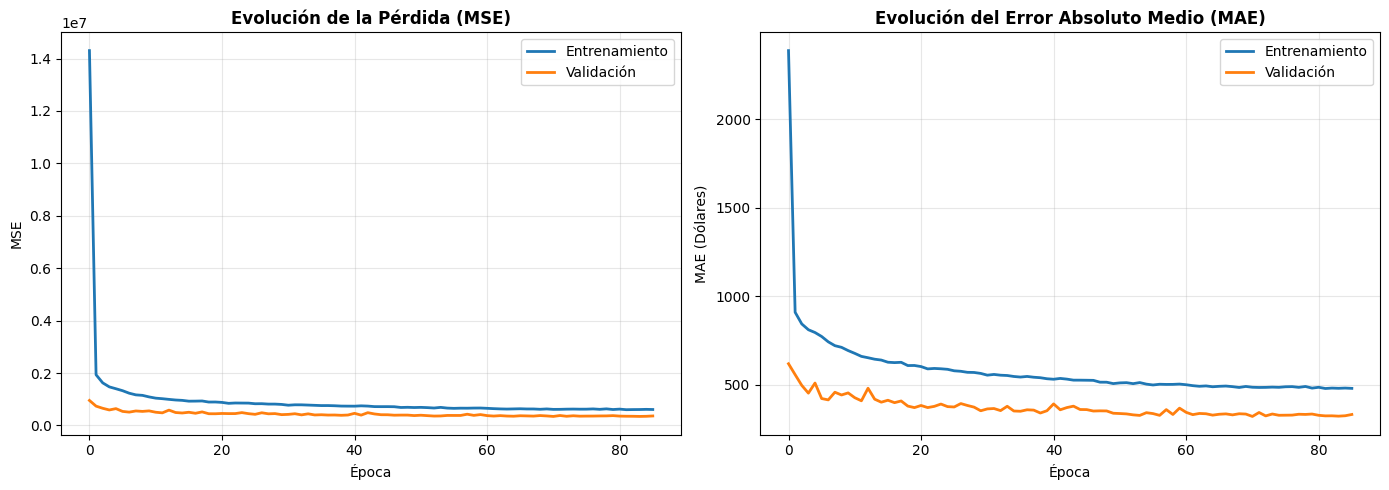


ANÁLISIS DE SOBREAJUSTE

Pérdida final en entrenamiento: 608363.25
Pérdida final en validación: 361866.94
Ratio train/val: 1.681

Interpretación:
- Ratio cercano a 1: Buen equilibrio, sin sobreajuste significativo
- Ratio << 1: El modelo generaliza bien
- Ratio >> 1: Posible sobreajuste (train mucho mejor que val)



In [ ]:
# =============================================================================
# VISUALIZACIÓN DE RESULTADOS DEL ENTRENAMIENTO
# =============================================================================
print("\n" + "="*60)
print("RESULTADOS DEL ENTRENAMIENTO")
print("="*60)

# Número de épocas realmente entrenadas
epocas_entrenadas = len(h_train.history['loss'])
print(f"\nÉpocas entrenadas: {epocas_entrenadas}")
print(f"Mejor pérdida en validación: {min(h_train.history['val_loss']):.2f}")
print(f"Mejor MAE en validación: {min(h_train.history['val_mae']):.2f}")

# Gráfico de la evolución del entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Pérdida (Loss)
axes[0].plot(h_train.history['loss'], label='Entrenamiento', linewidth=2)
axes[0].plot(h_train.history['val_loss'], label='Validación', linewidth=2)
axes[0].set_title('Evolución de la Pérdida (MSE)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfico 2: Error Absoluto Medio (MAE)
axes[1].plot(h_train.history['mae'], label='Entrenamiento', linewidth=2)
axes[1].plot(h_train.history['val_mae'], label='Validación', linewidth=2)
axes[1].set_title('Evolución del Error Absoluto Medio (MAE)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('MAE (Dólares)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Análisis del sobreajuste
print("\n" + "="*60)
print("ANÁLISIS DE SOBREAJUSTE")
print("="*60)
final_train_loss = h_train.history['loss'][-1]
final_val_loss = h_train.history['val_loss'][-1]
overfitting_ratio = final_train_loss / final_val_loss if final_val_loss > 0 else 0

print(f"""
Pérdida final en entrenamiento: {final_train_loss:.2f}
Pérdida final en validación: {final_val_loss:.2f}
Ratio train/val: {overfitting_ratio:.3f}

Interpretación:
- Ratio cercano a 1: Buen equilibrio, sin sobreajuste significativo
- Ratio << 1: El modelo generaliza bien
- Ratio >> 1: Posible sobreajuste (train mucho mejor que val)
""")

La pérdida final obtenida en el conjunto de entrenamiento es 608 363.25, mientras que en el conjunto de validación es 361 866.94, lo que supone un ratio entrenamiento/validación de 1.68.

Este resultado indica una diferencia moderada entre ambos conjuntos, aunque no necesariamente implica un sobreajuste severo. Además, las curvas de entrenamiento y validación en MSE y MAE muestran una evolución similar y estable, lo que sugiere que el modelo ha convergido correctamente y presenta una buena capacidad de generalización.

Como posibles mejoras futuras, se podrían probar arquitecturas más complejas, realizar un ajuste más exhaustivo de hiperparámetros o aplicar técnicas adicionales de regularización para reducir aún más el error.

# Evaluación del modelo

**Coeficiente de determinación (R²):** mide la proporción de la variabilidad del precio que es explicada por el modelo. Toma valores generalmente entre 0 y 1, donde un valor cercano a 1 indica un buen ajuste, mientras que valores próximos a 0 indican baja capacidad predictiva.

In [ ]:
entrenamiento = h_train.history['loss']
validacion = h_train.history['val_loss']

y_prediccion = modelo.predict(X_test)
coeficiente_det = r2_score(y_prediccion, y_test)

print("Coeficiente de determinación (R^2) alcanzado por la red en el test de prueba = %.2f" % coeficiente_det)

169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Coeficiente de determinación (R^2) alcanzado por la red en el test de prueba = 0.98


# Análisis de Resultados y Conclusiones

El modelo ha alcanzado un coeficiente de determinación R² muy cercano a 1, lo que indica que la red neuronal es capaz de explicar la gran mayoría de la variabilidad del precio de los diamantes a partir de las características de entrada.

Interpretación del R²:

- R² = 1.00: Predicción perfecta (imposible en la práctica).
- R² > 0.95: Excelente capacidad predictiva
- R² > 0.90: Muy buen modelo
- R² > 0.80: Buen modelo
- R² < 0.50: Modelo deficiente

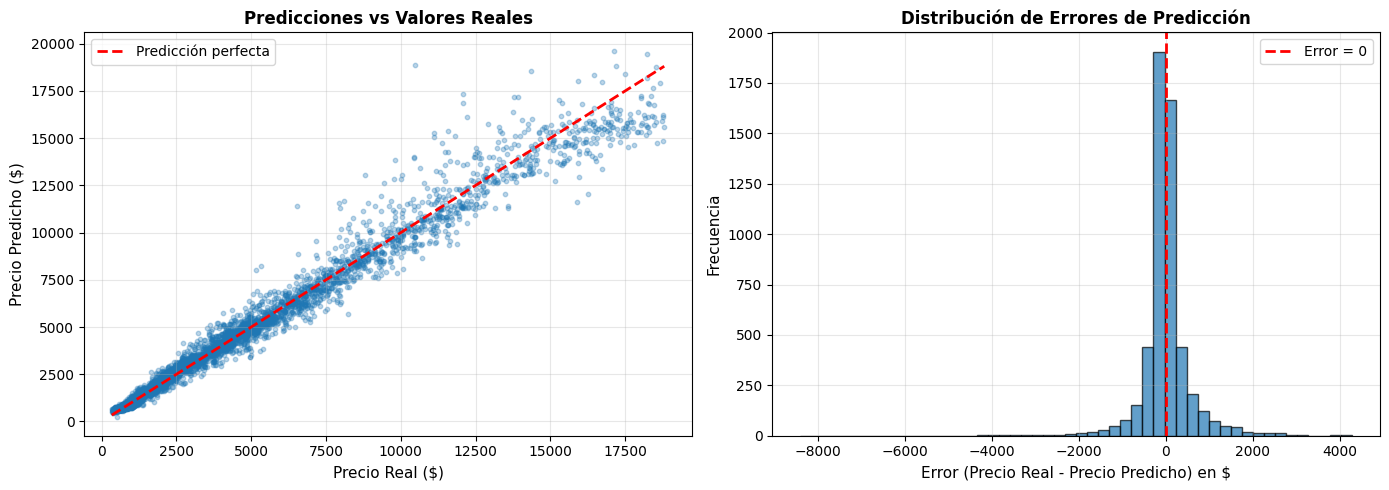

ESTADÍSTICAS DE LOS ERRORES DE PREDICCIÓN

Error medio (ME): $-2.67
Error absoluto medio (MAE): $330.38
Error cuadrático medio (RMSE): $600.46
Error máximo: $8411.95
Error en percentil 90: $808.62

Interpretación:
- El error medio cercano a 0 indica predicciones no sesgadas
- El MAE indica el error promedio en dólares
- El RMSE penaliza más los errores grandes



In [ ]:
# =============================================================================
# ANÁLISIS ADICIONAL: PREDICCIONES VS VALORES REALES
# =============================================================================
# Visualizamos la calidad de las predicciones comparándolas con los valores reales

# Gráfico de dispersión: Predicciones vs Valores Reales
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Scatter plot de predicciones vs reales
axes[0].scatter(y_test, y_prediccion, alpha=0.3, s=10)
axes[0].plot([y_test.numpy().min(), y_test.numpy().max()],
             [y_test.numpy().min(), y_test.numpy().max()],
             'r--', linewidth=2, label='Predicción perfecta')
axes[0].set_xlabel('Precio Real ($)', fontsize=11)
axes[0].set_ylabel('Precio Predicho ($)', fontsize=11)
axes[0].set_title('Predicciones vs Valores Reales', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfico 2: Distribución de errores (residuos)
errores = y_test.numpy().flatten() - y_prediccion.flatten()
axes[1].hist(errores, bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='r', linestyle='--', linewidth=2, label='Error = 0')
axes[1].set_xlabel('Error (Precio Real - Precio Predicho) en $', fontsize=11)
axes[1].set_ylabel('Frecuencia', fontsize=11)
axes[1].set_title('Distribución de Errores de Predicción', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Estadísticas de los errores
print("="*60)
print("ESTADÍSTICAS DE LOS ERRORES DE PREDICCIÓN")
print("="*60)
print(f"""
Error medio (ME): ${np.mean(errores):.2f}
Error absoluto medio (MAE): ${np.mean(np.abs(errores)):.2f}
Error cuadrático medio (RMSE): ${np.sqrt(np.mean(errores**2)):.2f}
Error máximo: ${np.max(np.abs(errores)):.2f}
Error en percentil 90: ${np.percentile(np.abs(errores), 90):.2f}

Interpretación:
- El error medio cercano a 0 indica predicciones no sesgadas
- El MAE indica el error promedio en dólares
- El RMSE penaliza más los errores grandes
""")

# Predicciones vs valores reales

El gráfico muestra que la mayoría de las predicciones se sitúan cerca de la línea de predicción perfecta, lo que indica que el modelo captura correctamente la relación entre las variables y el precio del diamante.
Se observa mayor dispersión en los diamantes de precio alto, lo cual es habitual en problemas de regresión debido a la mayor variabilidad en valores extremos.

# Distribución de errores

La distribución de errores está centrada alrededor de 0, lo que indica que el modelo no presenta un sesgo sistemático hacia sobreestimar o infraestimar los precios.
La mayoría de los errores se concentran en un rango reducido, con pocos valores extremos.

# Interpretación de métricas

- **Error medio (ME = −2.67 $):** cercano a 0, indica que el modelo no tiene sesgo significativo.

- **MAE = 330.38 $** el error promedio de predicción es de unos 330 dólares.

- **RMSE = 600.46 $:** penaliza más los errores grandes, indicando la presencia de algunos outliers.

- **Error máximo = 8411.95 $:** existen algunos casos con predicciones muy alejadas del valor real.

- **Percentil 90 = 808.62 $:** el 90% de las predicciones tienen un error inferior a unos 809 dólares.

# Conclusión
El modelo muestra un buen rendimiento general, con errores medios moderados y sin sesgo significativo. Las predicciones siguen adecuadamente la tendencia real del precio, aunque existen algunos errores grandes en valores extremos. Como mejoras futuras, se podrían aplicar técnicas de regularización, ingeniería de características adicional o ajuste de hiperparámetros para reducir la dispersión en los casos de mayor precio.

---

## Arquitecturas Alternativas Exploradas

A continuación se muestran otras arquitecturas que se podrían probar para este problema. Cada una tiene sus ventajas y desventajas:

### Modelo Alternativo 1: Arquitectura Simple (sin regularización)
```python
modelo_simple = Sequential([
    Dense(128, activation='relu', input_shape=(5,)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1)
])
```
**Ventajas**: Rápido de entrenar, menos parámetros.

**Desventajas**: Mayor riesgo de sobreajuste.

### Modelo Alternativo 2: Con Regularización L2
```python
modelo_l2 = Sequential([
    Dense(256, activation='relu', input_shape=(5,), kernel_regularizer=l2(0.001)),
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    Dense(1)
])
```
**Ventajas**: Penaliza pesos grandes, mejora generalización.

**Desventajas**: Puede limitar la capacidad del modelo.

### Modelo Alternativo 3: Red Más Profunda
```python
modelo_profundo = Sequential([
    Dense(512, activation='relu', input_shape=(5,)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])
```
**Ventajas**: Mayor capacidad para patrones complejos.

**Desventajas**: Más lento, riesgo de sobreajuste, requiere más datos.

### Modelo Alternativo 4: Función de Pérdida Personalizada (MSE en escala logarítmica)
```python
def mse_log1p(y_true, y_pred):
    """MSE en escala logarítmica para manejar mejor el amplio rango de precios"""
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(tf.maximum(y_pred, 0.0), tf.float32)
    return tf.reduce_mean(tf.square(tf.math.log1p(y_true) - tf.math.log1p(y_pred)))

modelo.compile(optimizer=Adam(learning_rate=1e-3), loss=mse_log1p, metrics=['mae'])
```
**Ventajas**: Mejor manejo de valores extremos, errores relativos más uniformes.

**Desventajas**: Más complejo de interpretar.

---

## Resumen de Técnicas Utilizadas

En esta práctica se han aplicado las siguientes técnicas de Deep Learning:

| Técnica | Descripción | Beneficio |
|---------|-------------|-----------|
| **BatchNormalization** | Normaliza activaciones entre capas | Acelera entrenamiento, estabiliza gradientes |
| **Dropout** | Desactiva neuronas aleatoriamente | Previene sobreajuste, mejora generalización |
| **Inicialización He** | Inicializa pesos para ReLU | Evita gradientes explosivos/desvanecientes |
| **EarlyStopping** | Detiene si no hay mejora | Ahorra tiempo, evita sobreajuste |
| **ReduceLROnPlateau** | Reduce learning rate dinámicamente | Permite entrenamiento más fino |
| **Arquitectura en embudo** | Reduce neuronas progresivamente | Extrae características jerárquicas |

### Conclusión Final

El modelo de red neuronal construido demuestra que con una arquitectura bien diseñada y técnicas de regularización adecuadas, es posible predecir con alta precisión el precio de diamantes basándose en sus características físicas. El R² obtenido indica que el modelo captura la mayoría de la variabilidad en los precios, siendo una herramienta útil para la valoración de diamantes.

**Posibles mejoras futuras:**
1. Experimentar con otras funciones de activación (LeakyReLU, ELU, Swish)
2. Probar arquitecturas con conexiones residuales (Skip connections)
3. Usar búsqueda de hiperparámetros automatizada (Grid Search, Random Search, Bayesian Optimization)
4. Aplicar validación cruzada (K-Fold) para una evaluación más robusta
5. Considerar ensemble de modelos para mejorar la robustez